# Proyecto "Estimación de los niveles de obesidad en función de los hábitos alimentarios y la condición física"

Para realizar este proyecto se utilizará el dataset ObesityDataSet_raw_and_data_sinthetic.csv tomado de la página web https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

Importamos las librerías necesarias para el análisis de datos y el entrenamiento del modelo.

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import Funciones as f
import modelos as m
import matplotlib.pyplot as plt
import streamlit as st
import plotly.express as px

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

## Carguemos el Dataset

In [74]:
df=pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

In [75]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


Analizamos los datos que contiene el dataset

In [76]:
f.explorar_df(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

Renombramos columnas

In [77]:
df = df.rename(columns={
    "Gender": "género",
    "Age": "edad",
    "Height": "altura",
    "Weight": "peso",
    "family_history_with_overweight": "f_con_sobrepeso",
    "SMOKE": "fuma",
    "NObeyesdad": "nivel_obesidad"
})


# Diccionario de las variables del estudio:

`género`= género (Femenino/Masculino)

`edad` = edad de la persona

`altura` = altura en metros

`peso` = peso en kilogramos

`f_con_sobrepeso` = antecedentes familiares con sobrepeso, ¿Algún familiar ha sufrido o sufre de sobrepeso?

`FAVC` = ¿Comes frecuentemente alimentos con alto contenido calórico?

`FCVC` = ¿Sueles comer verduras en tus comidas?		

`NCP` =	¿Cuántas comidas principales realizas diariamente?

`CAEC` = ¿Comes algún alimento entre las comidas?	

`fuma` = ¿Fuma usted?

`CH2O` = ¿Cuánta agua bebes diariamente?	

`SCC` =	¿Controlas las calorías que consumes diariamente?	

`FAF` = ¿Con qué frecuencia realizas actividad física?	

`TUE` =	¿Cuánto tiempo utilizas dispositivos tecnológicos como celular, videojuegos, televisión, computadora y otros?

`CALC` = ¿Con qué frecuencia bebes alcohol?	

`MTRANS` = ¿Qué medio de transporte utilizas habitualmente?		

`nivel_obesidad` = Nivel de obesidad

Ahora las columnas son:

In [78]:
df.columns

Index(['género', 'edad', 'altura', 'peso', 'f_con_sobrepeso', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'fuma', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS',
       'nivel_obesidad'],
      dtype='object')

## Limpieza de los datos

Limpiaremos los datos y veremos los valores en cada columna para su análisis.

In [79]:
f.categorico(df,"nivel_obesidad")

nivel_obesidad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64
['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']
7


In [80]:
f.asignar_secciones(df)

,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Peso normal
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Peso normal
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Peso normal
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Sobrepeso nivel I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Sobrepeso nivel II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesidad tipo III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesidad tipo III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesidad tipo III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesidad tipo III


Veamos la variable a estudiar que es nivel_obesidad

In [81]:
# Definimos el orden lógico de las categorías para el gráfico
orden_categorias = [
    "Peso insuficiente", 
    "Peso normal", 
    "Sobrepeso nivel I", 
    "Sobrepeso nivel II", 
    "Obesidad tipo I", 
    "Obesidad tipo II", 
    "Obesidad tipo III"
]

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Peso insuficiente'),
  Text(1, 0, 'Peso normal'),
  Text(2, 0, 'Sobrepeso nivel I'),
  Text(3, 0, 'Sobrepeso nivel II'),
  Text(4, 0, 'Obesidad tipo I'),
  Text(5, 0, 'Obesidad tipo II'),
  Text(6, 0, 'Obesidad tipo III')])

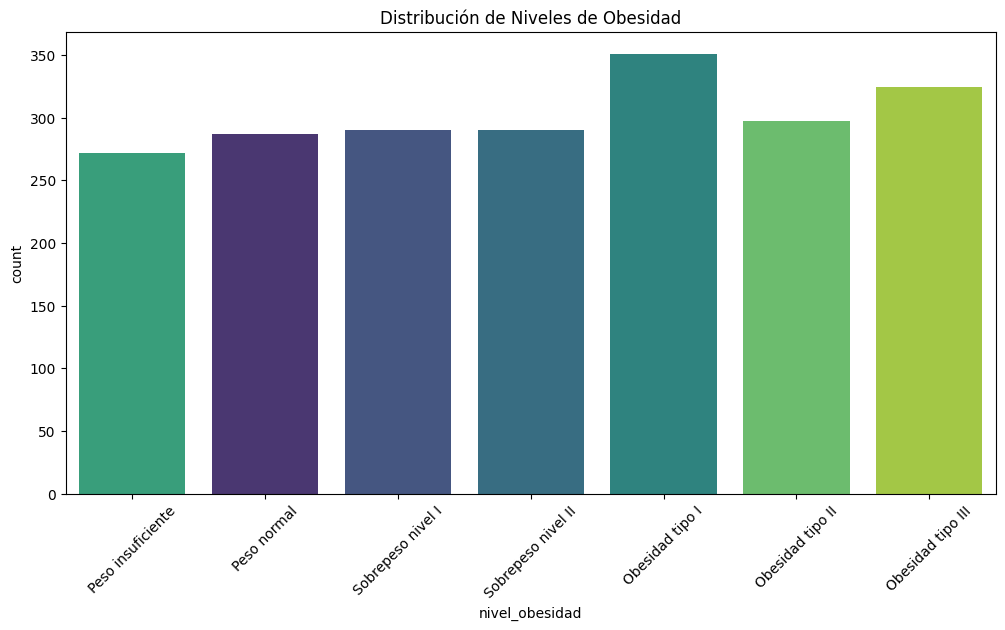

In [82]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='nivel_obesidad', order=orden_categorias, hue='nivel_obesidad', palette="viridis", legend=False)
plt.title('Distribución de Niveles de Obesidad')
plt.xticks(rotation=45)



Veamos duplicados

In [83]:
f.ver_duplicados(df)

,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Peso insuficiente
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Peso normal
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Sobrepeso nivel I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Sobrepeso nivel I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Sobrepeso nivel I
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Peso normal
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Peso normal
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Peso normal
467,Male,22.0,1.74,75.0,yes,yes,3.0,3.0,Frequently,no,1.0,no,1.0,0.0,no,Automobile,Peso normal
496,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Peso insuficiente


,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Peso insuficiente
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Peso normal
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Sobrepeso nivel I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Sobrepeso nivel I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Sobrepeso nivel I
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Peso normal
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Peso normal
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Peso normal
467,Male,22.0,1.74,75.0,yes,yes,3.0,3.0,Frequently,no,1.0,no,1.0,0.0,no,Automobile,Peso normal
496,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Peso insuficiente


Borramos los duplicados del dataset

In [84]:
df_clean = df.drop_duplicates()

In [85]:
df_clean.shape

(2087, 17)

Observamos como se distribuyen los datos en la columna 'nivel_obesidad'

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Peso insuficiente'),
  Text(1, 0, 'Peso normal'),
  Text(2, 0, 'Sobrepeso nivel I'),
  Text(3, 0, 'Sobrepeso nivel II'),
  Text(4, 0, 'Obesidad tipo I'),
  Text(5, 0, 'Obesidad tipo II'),
  Text(6, 0, 'Obesidad tipo III')])

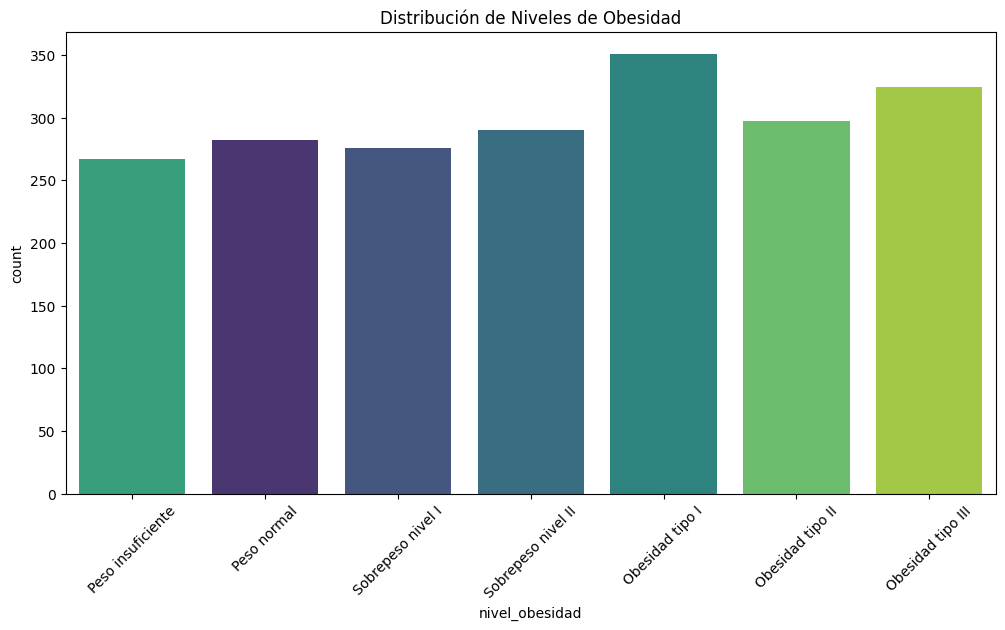

In [86]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, x='nivel_obesidad', order=orden_categorias, hue='nivel_obesidad', palette="viridis", legend=False)
plt.title('Distribución de Niveles de Obesidad')
plt.xticks(rotation=45)

Al observar la variable 'nivel_obesidad' vemos que mantiene una homogeneidad en su distribución, por lo que no es necesario realizar ninguna adecuación o agregar elementos.

In [87]:
f.categorico(df_clean,"CAEC")

CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64
['Sometimes' 'Frequently' 'Always' 'no']
4


Llevamos nuestras variables de estudio al lenguaje español.

In [88]:
f.cambio(df_clean,'CAEC')

c:\Users\tachi\Documents\ironhack\Proyecto\Proyecto\Funciones.py:105: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,A veces,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Peso normal
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,A veces,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Peso normal
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,A veces,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Peso normal
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,A veces,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Sobrepeso nivel I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,A veces,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Sobrepeso nivel II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,A veces,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesidad tipo III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,A veces,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesidad tipo III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,A veces,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesidad tipo III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,A veces,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesidad tipo III


In [89]:
f.categorico(df_clean,'género')

género
Male      1052
Female    1035
Name: count, dtype: int64
['Female' 'Male']
2


In [90]:
f.se(df_clean,'género')

c:\Users\tachi\Documents\ironhack\Proyecto\Proyecto\Funciones.py:115: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,femenino,21.000000,1.620000,64.000000,yes,no,2.0,3.0,A veces,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Peso normal
1,femenino,21.000000,1.520000,56.000000,yes,no,3.0,3.0,A veces,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Peso normal
2,masculino,23.000000,1.800000,77.000000,yes,no,2.0,3.0,A veces,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Peso normal
3,masculino,27.000000,1.800000,87.000000,no,no,3.0,3.0,A veces,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Sobrepeso nivel I
4,masculino,22.000000,1.780000,89.800000,no,no,2.0,1.0,A veces,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Sobrepeso nivel II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,femenino,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,A veces,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesidad tipo III
2107,femenino,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,A veces,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesidad tipo III
2108,femenino,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,A veces,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesidad tipo III
2109,femenino,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,A veces,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesidad tipo III


In [91]:
f.categorico(df_clean,'CALC')

CALC
Sometimes     1380
no             636
Frequently      70
Always           1
Name: count, dtype: int64
['no' 'Sometimes' 'Frequently' 'Always']
4


In [92]:
f.cambio(df_clean,'CALC')

c:\Users\tachi\Documents\ironhack\Proyecto\Proyecto\Funciones.py:105: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,femenino,21.000000,1.620000,64.000000,yes,no,2.0,3.0,A veces,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Peso normal
1,femenino,21.000000,1.520000,56.000000,yes,no,3.0,3.0,A veces,yes,3.000000,yes,3.000000,0.000000,A veces,Public_Transportation,Peso normal
2,masculino,23.000000,1.800000,77.000000,yes,no,2.0,3.0,A veces,no,2.000000,no,2.000000,1.000000,Con frecuencia,Public_Transportation,Peso normal
3,masculino,27.000000,1.800000,87.000000,no,no,3.0,3.0,A veces,no,2.000000,no,2.000000,0.000000,Con frecuencia,Walking,Sobrepeso nivel I
4,masculino,22.000000,1.780000,89.800000,no,no,2.0,1.0,A veces,no,2.000000,no,0.000000,0.000000,A veces,Public_Transportation,Sobrepeso nivel II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,femenino,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,A veces,no,1.728139,no,1.676269,0.906247,A veces,Public_Transportation,Obesidad tipo III
2107,femenino,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,A veces,no,2.005130,no,1.341390,0.599270,A veces,Public_Transportation,Obesidad tipo III
2108,femenino,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,A veces,no,2.054193,no,1.414209,0.646288,A veces,Public_Transportation,Obesidad tipo III
2109,femenino,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,A veces,no,2.852339,no,1.139107,0.586035,A veces,Public_Transportation,Obesidad tipo III


In [93]:
f.categorico(df_clean,"FCVC")

FCVC
3.000000    647
2.000000    581
1.000000     33
2.971574      2
2.630137      2
           ... 
2.886260      1
2.658112      1
2.027574      1
1.123939      1
2.591439      1
Name: count, Length: 810, dtype: int64
[2.       3.       1.       2.450218 2.880161 2.00876  2.596579 2.591439
 2.392665 1.123939 2.027574 2.658112 2.88626  2.714447 2.750715 1.4925
 2.205439 2.059138 2.310423 2.823179 2.052932 2.596364 2.767731 2.815157
 2.737762 2.568063 2.524428 2.971574 1.0816   1.270448 1.344854 2.959658
 2.725282 2.844607 2.44004  2.432302 2.592247 2.449267 2.929889 2.015258
 1.031149 1.592183 1.21498  1.522001 2.703436 2.362918 2.14084  2.5596
 2.336044 1.813234 2.724285 2.71897  1.133844 1.757466 2.979383 2.204914
 2.927218 2.88853  2.890535 2.530066 2.241606 1.003566 2.652779 2.897899
 2.483979 2.945967 2.478891 2.784464 1.005578 2.938031 2.842102 1.889199
 2.943749 2.33998  1.950742 2.277436 2.371338 2.984425 2.977018 2.663421
 2.753752 2.318355 2.594653 2.886157 2.967853 2.619835

In [94]:
f.categorico(df_clean,'f_con_sobrepeso')

f_con_sobrepeso
yes    1722
no      365
Name: count, dtype: int64
['yes' 'no']
2


In [95]:
f.si_no(df_clean,"f_con_sobrepeso")

c:\Users\tachi\Documents\ironhack\Proyecto\Proyecto\Funciones.py:110: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,femenino,21.000000,1.620000,64.000000,Si,no,2.0,3.0,A veces,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Peso normal
1,femenino,21.000000,1.520000,56.000000,Si,no,3.0,3.0,A veces,yes,3.000000,yes,3.000000,0.000000,A veces,Public_Transportation,Peso normal
2,masculino,23.000000,1.800000,77.000000,Si,no,2.0,3.0,A veces,no,2.000000,no,2.000000,1.000000,Con frecuencia,Public_Transportation,Peso normal
3,masculino,27.000000,1.800000,87.000000,No,no,3.0,3.0,A veces,no,2.000000,no,2.000000,0.000000,Con frecuencia,Walking,Sobrepeso nivel I
4,masculino,22.000000,1.780000,89.800000,No,no,2.0,1.0,A veces,no,2.000000,no,0.000000,0.000000,A veces,Public_Transportation,Sobrepeso nivel II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,femenino,20.976842,1.710730,131.408528,Si,yes,3.0,3.0,A veces,no,1.728139,no,1.676269,0.906247,A veces,Public_Transportation,Obesidad tipo III
2107,femenino,21.982942,1.748584,133.742943,Si,yes,3.0,3.0,A veces,no,2.005130,no,1.341390,0.599270,A veces,Public_Transportation,Obesidad tipo III
2108,femenino,22.524036,1.752206,133.689352,Si,yes,3.0,3.0,A veces,no,2.054193,no,1.414209,0.646288,A veces,Public_Transportation,Obesidad tipo III
2109,femenino,24.361936,1.739450,133.346641,Si,yes,3.0,3.0,A veces,no,2.852339,no,1.139107,0.586035,A veces,Public_Transportation,Obesidad tipo III


In [96]:
f.si_no(df_clean,"fuma")

c:\Users\tachi\Documents\ironhack\Proyecto\Proyecto\Funciones.py:110: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,femenino,21.000000,1.620000,64.000000,Si,no,2.0,3.0,A veces,No,2.000000,no,0.000000,1.000000,no,Public_Transportation,Peso normal
1,femenino,21.000000,1.520000,56.000000,Si,no,3.0,3.0,A veces,Si,3.000000,yes,3.000000,0.000000,A veces,Public_Transportation,Peso normal
2,masculino,23.000000,1.800000,77.000000,Si,no,2.0,3.0,A veces,No,2.000000,no,2.000000,1.000000,Con frecuencia,Public_Transportation,Peso normal
3,masculino,27.000000,1.800000,87.000000,No,no,3.0,3.0,A veces,No,2.000000,no,2.000000,0.000000,Con frecuencia,Walking,Sobrepeso nivel I
4,masculino,22.000000,1.780000,89.800000,No,no,2.0,1.0,A veces,No,2.000000,no,0.000000,0.000000,A veces,Public_Transportation,Sobrepeso nivel II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,femenino,20.976842,1.710730,131.408528,Si,yes,3.0,3.0,A veces,No,1.728139,no,1.676269,0.906247,A veces,Public_Transportation,Obesidad tipo III
2107,femenino,21.982942,1.748584,133.742943,Si,yes,3.0,3.0,A veces,No,2.005130,no,1.341390,0.599270,A veces,Public_Transportation,Obesidad tipo III
2108,femenino,22.524036,1.752206,133.689352,Si,yes,3.0,3.0,A veces,No,2.054193,no,1.414209,0.646288,A veces,Public_Transportation,Obesidad tipo III
2109,femenino,24.361936,1.739450,133.346641,Si,yes,3.0,3.0,A veces,No,2.852339,no,1.139107,0.586035,A veces,Public_Transportation,Obesidad tipo III


In [97]:
f.si_no(df_clean,"FAVC")

c:\Users\tachi\Documents\ironhack\Proyecto\Proyecto\Funciones.py:110: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,femenino,21.000000,1.620000,64.000000,Si,No,2.0,3.0,A veces,No,2.000000,no,0.000000,1.000000,no,Public_Transportation,Peso normal
1,femenino,21.000000,1.520000,56.000000,Si,No,3.0,3.0,A veces,Si,3.000000,yes,3.000000,0.000000,A veces,Public_Transportation,Peso normal
2,masculino,23.000000,1.800000,77.000000,Si,No,2.0,3.0,A veces,No,2.000000,no,2.000000,1.000000,Con frecuencia,Public_Transportation,Peso normal
3,masculino,27.000000,1.800000,87.000000,No,No,3.0,3.0,A veces,No,2.000000,no,2.000000,0.000000,Con frecuencia,Walking,Sobrepeso nivel I
4,masculino,22.000000,1.780000,89.800000,No,No,2.0,1.0,A veces,No,2.000000,no,0.000000,0.000000,A veces,Public_Transportation,Sobrepeso nivel II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,femenino,20.976842,1.710730,131.408528,Si,Si,3.0,3.0,A veces,No,1.728139,no,1.676269,0.906247,A veces,Public_Transportation,Obesidad tipo III
2107,femenino,21.982942,1.748584,133.742943,Si,Si,3.0,3.0,A veces,No,2.005130,no,1.341390,0.599270,A veces,Public_Transportation,Obesidad tipo III
2108,femenino,22.524036,1.752206,133.689352,Si,Si,3.0,3.0,A veces,No,2.054193,no,1.414209,0.646288,A veces,Public_Transportation,Obesidad tipo III
2109,femenino,24.361936,1.739450,133.346641,Si,Si,3.0,3.0,A veces,No,2.852339,no,1.139107,0.586035,A veces,Public_Transportation,Obesidad tipo III


In [98]:
f.si_no(df_clean,"SCC")

c:\Users\tachi\Documents\ironhack\Proyecto\Proyecto\Funciones.py:110: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,femenino,21.000000,1.620000,64.000000,Si,No,2.0,3.0,A veces,No,2.000000,No,0.000000,1.000000,no,Public_Transportation,Peso normal
1,femenino,21.000000,1.520000,56.000000,Si,No,3.0,3.0,A veces,Si,3.000000,Si,3.000000,0.000000,A veces,Public_Transportation,Peso normal
2,masculino,23.000000,1.800000,77.000000,Si,No,2.0,3.0,A veces,No,2.000000,No,2.000000,1.000000,Con frecuencia,Public_Transportation,Peso normal
3,masculino,27.000000,1.800000,87.000000,No,No,3.0,3.0,A veces,No,2.000000,No,2.000000,0.000000,Con frecuencia,Walking,Sobrepeso nivel I
4,masculino,22.000000,1.780000,89.800000,No,No,2.0,1.0,A veces,No,2.000000,No,0.000000,0.000000,A veces,Public_Transportation,Sobrepeso nivel II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,femenino,20.976842,1.710730,131.408528,Si,Si,3.0,3.0,A veces,No,1.728139,No,1.676269,0.906247,A veces,Public_Transportation,Obesidad tipo III
2107,femenino,21.982942,1.748584,133.742943,Si,Si,3.0,3.0,A veces,No,2.005130,No,1.341390,0.599270,A veces,Public_Transportation,Obesidad tipo III
2108,femenino,22.524036,1.752206,133.689352,Si,Si,3.0,3.0,A veces,No,2.054193,No,1.414209,0.646288,A veces,Public_Transportation,Obesidad tipo III
2109,femenino,24.361936,1.739450,133.346641,Si,Si,3.0,3.0,A veces,No,2.852339,No,1.139107,0.586035,A veces,Public_Transportation,Obesidad tipo III


In [99]:
f.categorico(df_clean,"MTRANS")

MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64
['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
5


In [100]:
f.traspaso(df_clean,"MTRANS")

c:\Users\tachi\Documents\ironhack\Proyecto\Proyecto\Funciones.py:120: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,femenino,21.000000,1.620000,64.000000,Si,No,2.0,3.0,A veces,No,2.000000,No,0.000000,1.000000,no,transporte público,Peso normal
1,femenino,21.000000,1.520000,56.000000,Si,No,3.0,3.0,A veces,Si,3.000000,Si,3.000000,0.000000,A veces,transporte público,Peso normal
2,masculino,23.000000,1.800000,77.000000,Si,No,2.0,3.0,A veces,No,2.000000,No,2.000000,1.000000,Con frecuencia,transporte público,Peso normal
3,masculino,27.000000,1.800000,87.000000,No,No,3.0,3.0,A veces,No,2.000000,No,2.000000,0.000000,Con frecuencia,a pie,Sobrepeso nivel I
4,masculino,22.000000,1.780000,89.800000,No,No,2.0,1.0,A veces,No,2.000000,No,0.000000,0.000000,A veces,transporte público,Sobrepeso nivel II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,femenino,20.976842,1.710730,131.408528,Si,Si,3.0,3.0,A veces,No,1.728139,No,1.676269,0.906247,A veces,transporte público,Obesidad tipo III
2107,femenino,21.982942,1.748584,133.742943,Si,Si,3.0,3.0,A veces,No,2.005130,No,1.341390,0.599270,A veces,transporte público,Obesidad tipo III
2108,femenino,22.524036,1.752206,133.689352,Si,Si,3.0,3.0,A veces,No,2.054193,No,1.414209,0.646288,A veces,transporte público,Obesidad tipo III
2109,femenino,24.361936,1.739450,133.346641,Si,Si,3.0,3.0,A veces,No,2.852339,No,1.139107,0.586035,A veces,transporte público,Obesidad tipo III


# Data set de trabajo nos queda con 2087 datos sin nulos, ni duplicados. Listo para comenzar el análisis.

In [101]:
df_clean.head()

,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,femenino,21.0,1.62,64.0,Si,No,2.0,3.0,A veces,No,2.0,No,0.0,1.0,no,transporte público,Peso normal
1,femenino,21.0,1.52,56.0,Si,No,3.0,3.0,A veces,Si,3.0,Si,3.0,0.0,A veces,transporte público,Peso normal
2,masculino,23.0,1.80,77.0,Si,No,2.0,3.0,A veces,No,2.0,No,2.0,1.0,Con frecuencia,transporte público,Peso normal
3,masculino,27.0,1.80,87.0,No,No,3.0,3.0,A veces,No,2.0,No,2.0,0.0,Con frecuencia,a pie,Sobrepeso nivel I
4,masculino,22.0,1.78,89.8,No,No,2.0,1.0,A veces,No,2.0,No,0.0,0.0,A veces,transporte público,Sobrepeso nivel II


Generamos el nuevo csv de estudio con todos los datos a analizar

In [102]:
df_clean.to_csv('ObesityDataSet_clean.csv', index=False)

# Análisis exploratorio para el estudio de la obesidad 

Analicemos el genero de nuestra base de datos con un gráfico circular

In [103]:
# Contamos las frecuencias
df_counts = df_clean['género'].value_counts().reset_index()
df_counts.columns = ['género', 'cantidad']

# Graficamos usando la columna de números 'cantidad'
fig = px.pie(
    df_counts, 
    names='género', 
    values='cantidad', 
    title="Distribución por Género",
    hole=0.3,
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.show()


Análisis univariado de las variables numéricas

In [104]:
df_numerales=df_clean.select_dtypes(include=['int64', 'float64'])

In [105]:
df_numerales.columns

Index(['edad', 'altura', 'peso', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')

Veamos sus distribución

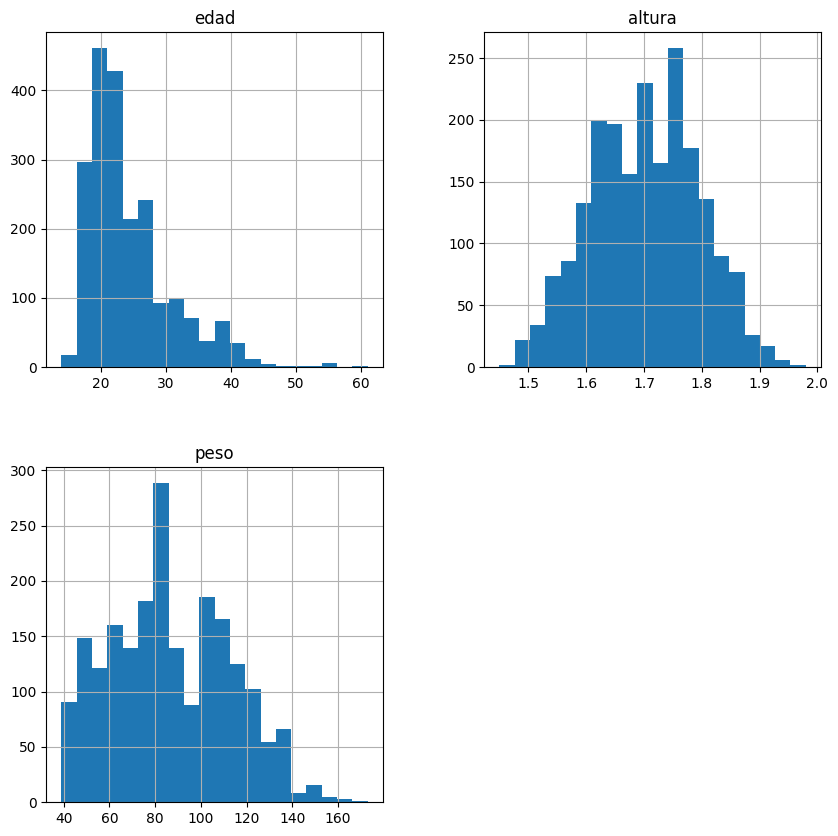

In [106]:
dfgrafico=df_clean[['edad','altura','peso']]
dfgrafico.hist(bins=20, figsize=(10,10))
plt.show()

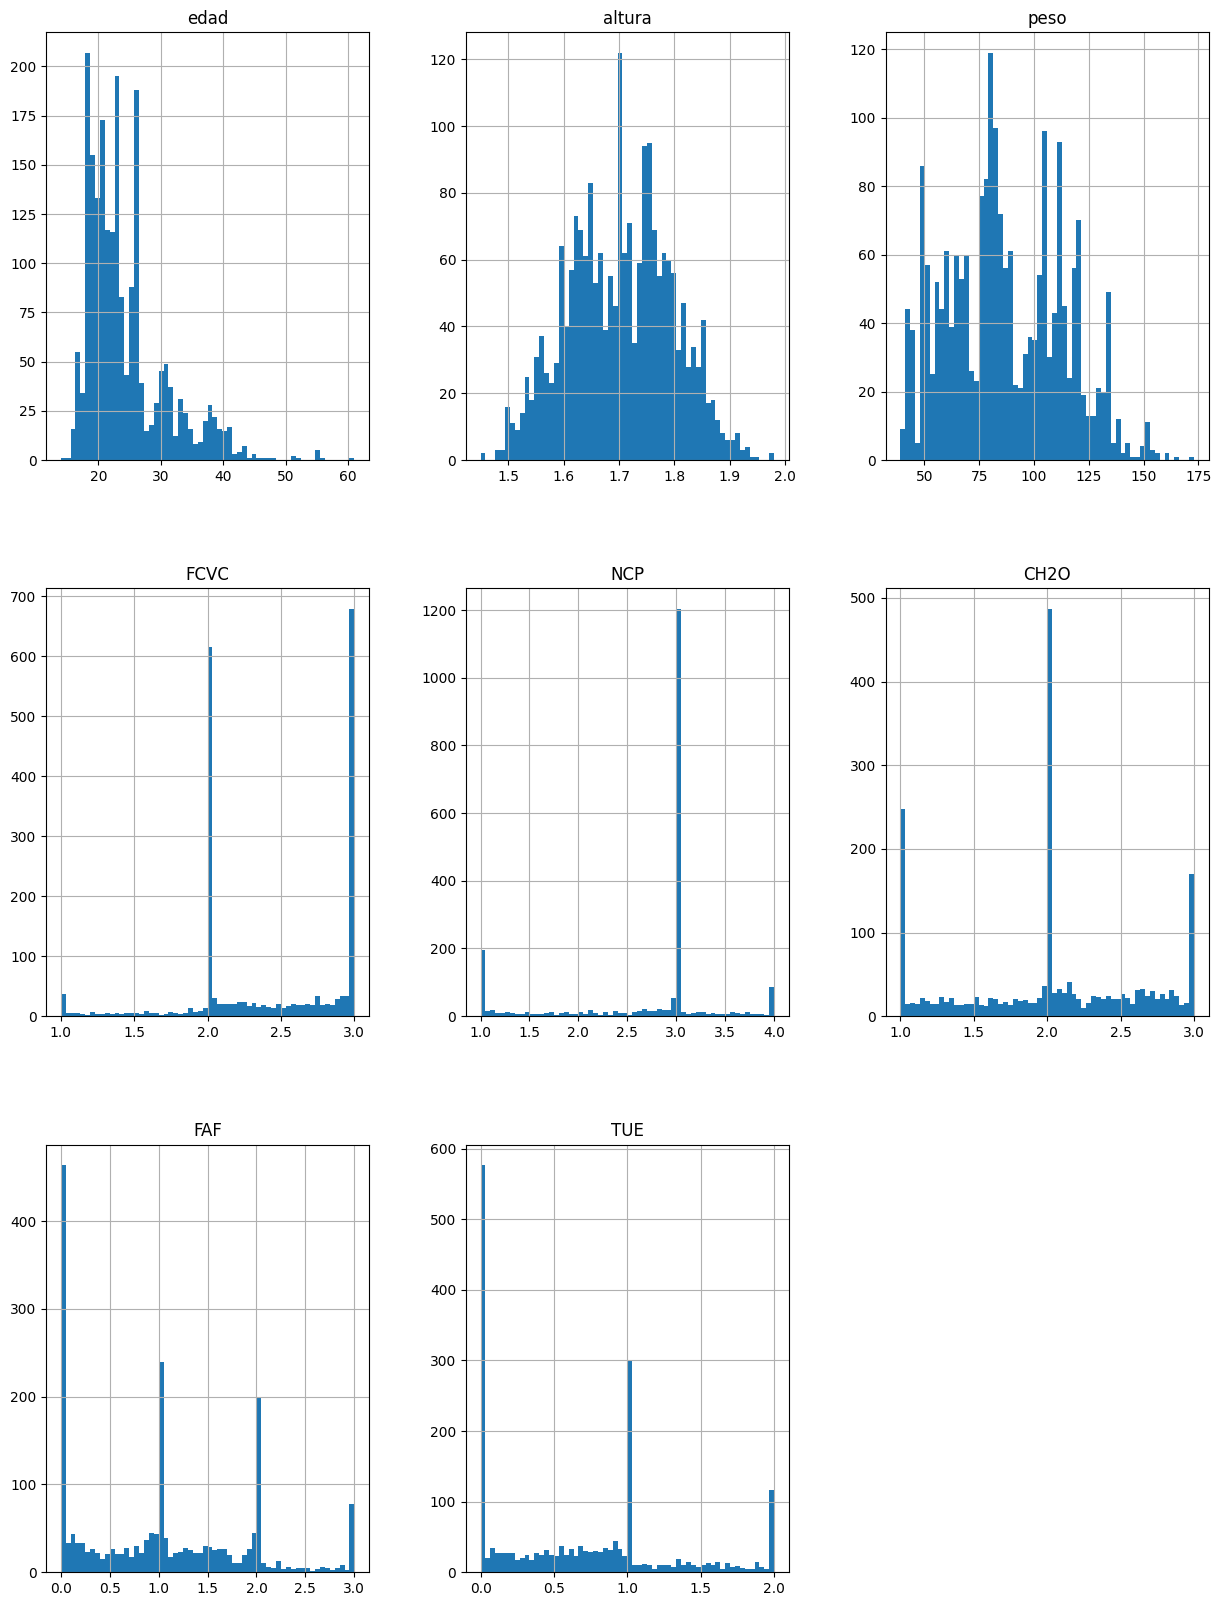

In [107]:
df_numerales.hist(figsize=(15, 20), bins=60, xlabelsize=10, ylabelsize=10);

Observemos si los datos de estudio estan normalizados observando la gráfica QQ

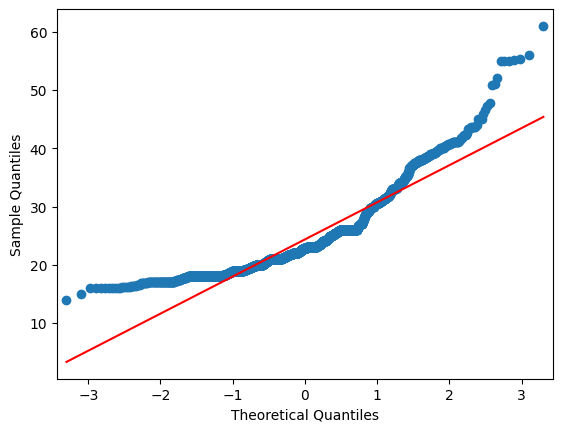

In [108]:
import statsmodels.api as sm
sm.qqplot(df_clean['edad'], line='s');

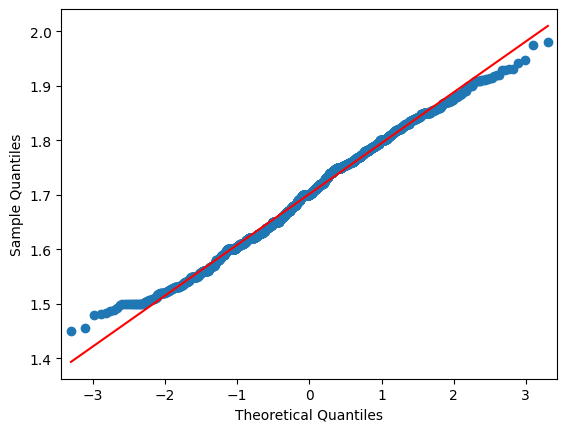

In [109]:
sm.qqplot(df['altura'], line='s');

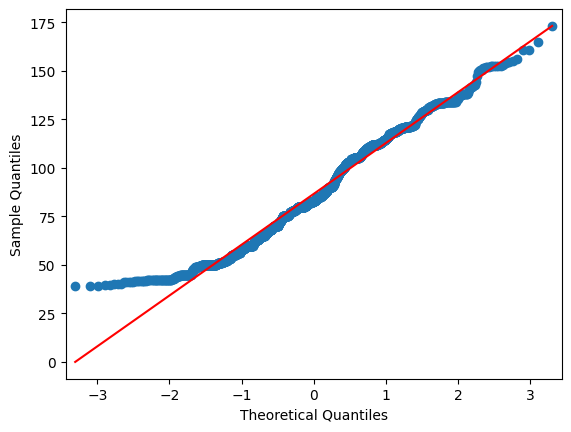

In [110]:
sm.qqplot(df['peso'], line='s');

Veamos la relación peso altura con respecto al nivel de obesidad

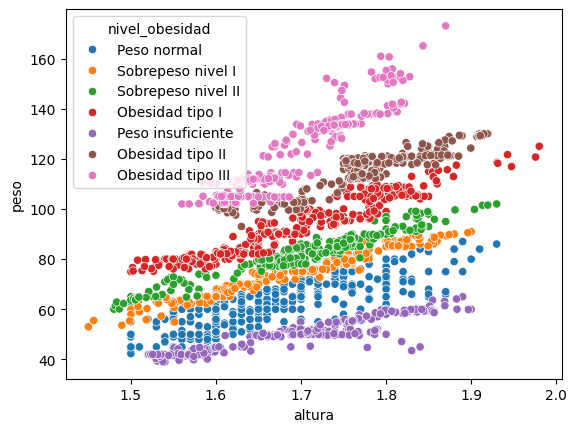

In [111]:
sns.scatterplot(data=df_clean, x='altura', y='peso', hue='nivel_obesidad')
plt.show()

# Investigación del análisis de datos 

Trabajaremos el dataset para el estudio de máquinas de aprendizaje (machine learning) para predecir el nivel de obesidad de una persona en función de sus hábitos alimenticios y su condición física.
Para esto hemos investigado la clasificación de los pesos en función del IMC, en la organización mundial de la salud (https://apps.who.int/nutrition/landscape/help.aspx?menu=0&helpid=420#:~:text=BMI%20%3C18.5:%20underweight,BMI%20%E2%89%A530.0:%20obesity.).

El IMC es un índice simple de peso/talla que se utiliza comúnmente para clasificar el bajo peso, el sobrepeso y la obesidad en adultos. Se define como el peso en kilogramos dividido entre el cuadrado de la altura en metros (kg/m² ) . Por ejemplo, un adulto que pesa 58 kg y mide 1,70 m tendrá un IMC de 20,1: IMC = 58 kg/(1,70 m ´ 1,70 m) = 20,1


| Rango IMC (kg/m²) |
| :--- |
| < 17,0 indica delgadez moderada y severa |
| < 18,5 indica bajo peso|
| 18,5 a 24,9 indica un peso normal|
| ≥ 25,0 indica sobrepeso |
| ≥ 30,0 indica obesidad |

como este estudio se centra en la obesidad se han definido 7 categorías que son:



| Categoría | Rango IMC (kg/m²) |
| :--- | :--- |
| Peso insuficiente | < 18.5 |
| Peso normal | 18.5 – 24.9 |
| Sobrepeso nivel I (Preobesidad leve) | 25.0 – 26.9 |
| Sobrepeso nivel II (Preobesidad moderada) | 27.0 – 29.9 |
| Obesidad tipo I (Moderada) | 30.0 – 34.9 |
| Obesidad tipo II (Severa) | 35.0 – 39.9 |
| Obesidad tipo III (Mórbida) | ≥ 40.0 |


# Haremos un estudio de KNN solo con los datos numéricos que tenemos

In [112]:
df_analisis=df[[ "edad","altura","peso","FCVC","NCP","FAF","TUE","nivel_obesidad"]]

Analizemos la relación entre las variables numéricas y el nivel de obesidad

In [113]:
analisis = df_analisis.drop("nivel_obesidad", axis=1)

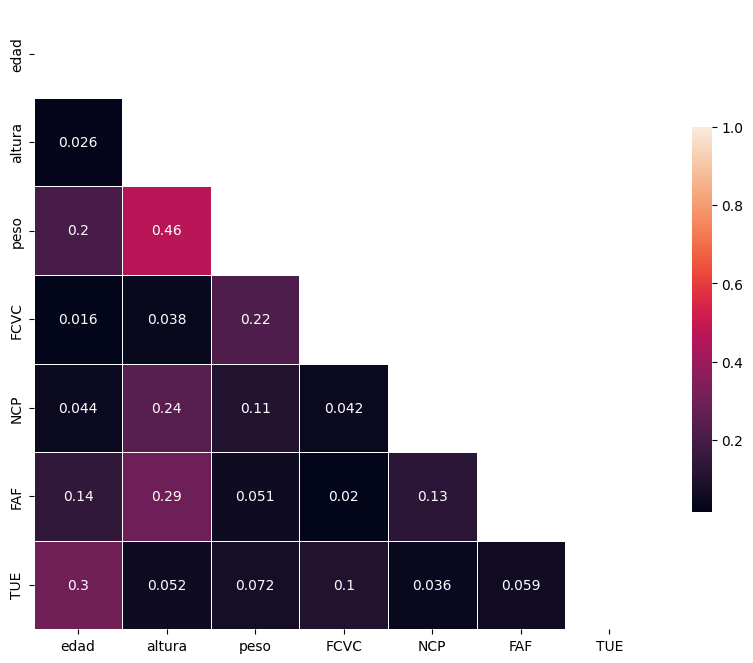

In [114]:
f.corr_heatmap(analisis)

Vemos las variables que se relacionan más como peso con altura, edad con TUE (tiempo en actividades como pc, móvil,etc.), altura con FAF(Actividades físicas), peso con FCVC (comer verduras)

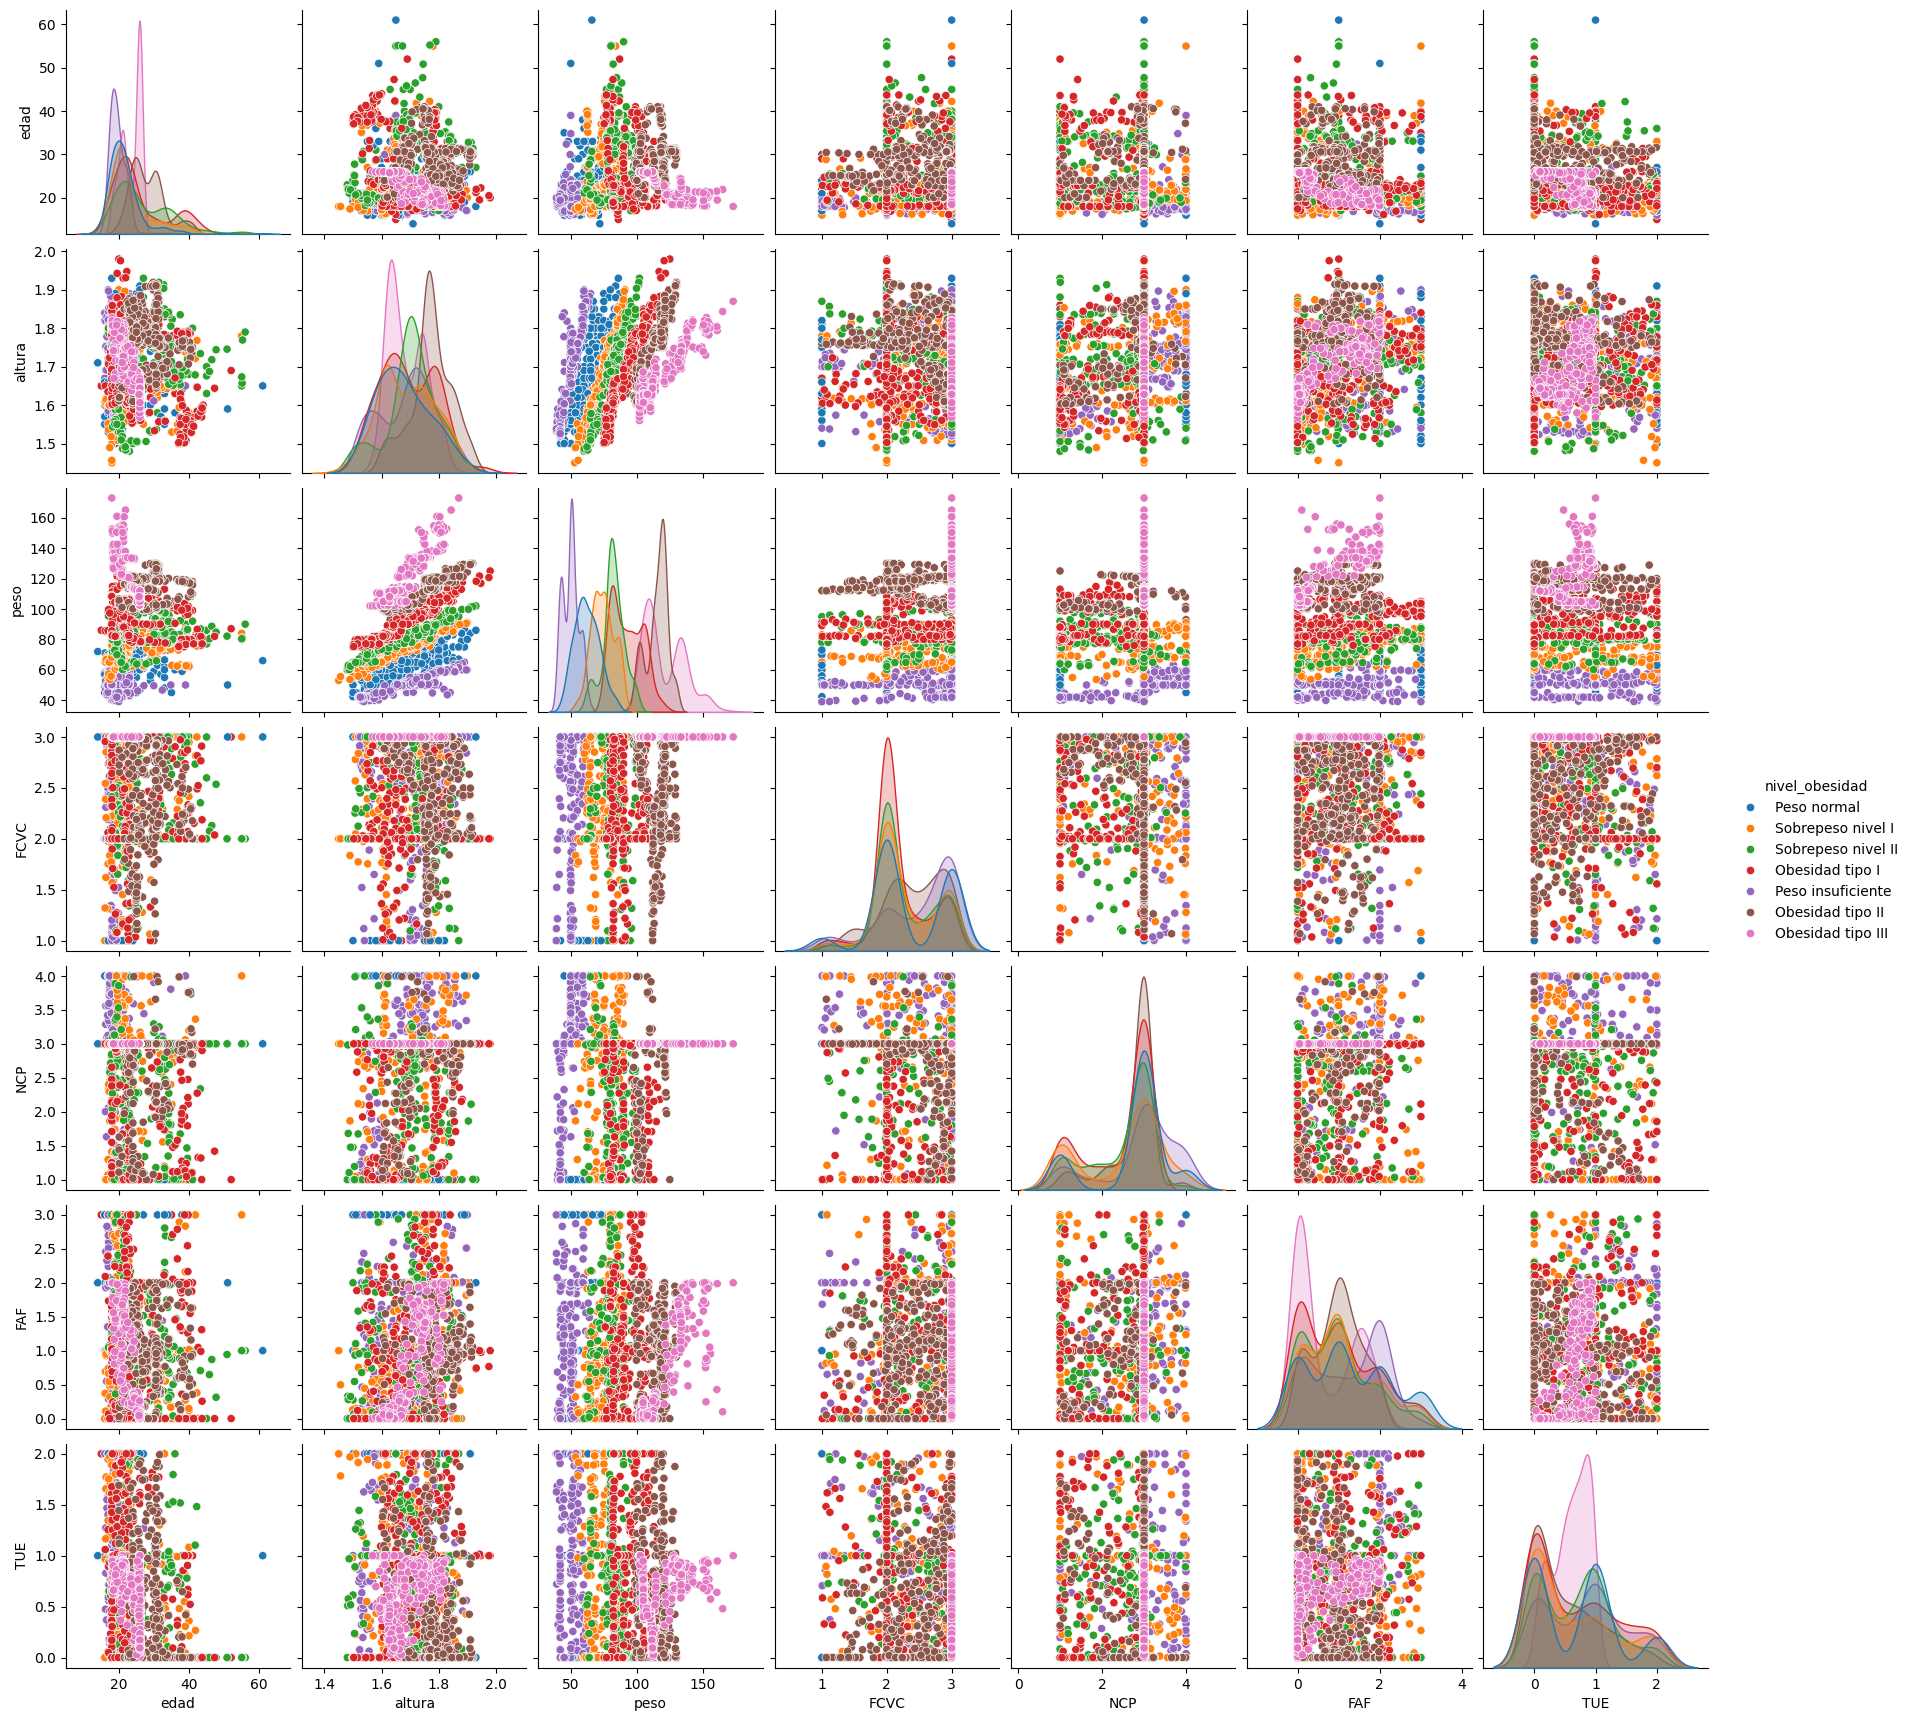

In [115]:
sns.pairplot(df_analisis, hue="nivel_obesidad")
plt.show()

Analicemos que ocurre con el estudio de KNN con solo los datos numéricos.

In [116]:
m.knn(df_analisis,"nivel_obesidad",3)

Accuracy:
0.8628841607565012
Precision:
0.8629095093989855
Recall:
0.8560877907612996
F1-score:
0.8546087398513682
Confusion Matrix:
[[62  0  1  0  1  1  2]
 [ 1 51  1  0  0  0  0]
 [ 0  1 68  0  0  0  0]
 [ 0  0  0 63  2  0  0]
 [ 1  0  0 16 31  9  0]
 [ 3  0  0  1  4 47  2]
 [ 7  1  0  0  3  1 43]]


# Ahora haremos el estudio de KNN con mapeo de las variables considerando todos los datos.

Pasamos todas las variables a numéricas con mapeo

In [117]:
df_estudio=f.traspaso_estudio(df_clean)

In [118]:
df_estudio

,género,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,NCP,CAEC,fuma,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,1,0,2.000000,0,0.000000,1.000000,0,0,1
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,1,1,3.000000,1,3.000000,0.000000,1,0,1
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,1,0,2.000000,0,2.000000,1.000000,2,0,1
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,1,0,2.000000,0,2.000000,0.000000,2,2,2
4,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,1,0,2.000000,0,0.000000,0.000000,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,1,0,1.728139,0,1.676269,0.906247,1,0,6
2107,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,1,0,2.005130,0,1.341390,0.599270,1,0,6
2108,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,1,0,2.054193,0,1.414209,0.646288,1,0,6
2109,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,1,0,2.852339,0,1.139107,0.586035,1,0,6


In [119]:
df_estudio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   género           2087 non-null   int64  
 1   edad             2087 non-null   float64
 2   altura           2087 non-null   float64
 3   peso             2087 non-null   float64
 4   f_con_sobrepeso  2087 non-null   int64  
 5   FAVC             2087 non-null   int64  
 6   FCVC             2087 non-null   float64
 7   NCP              2087 non-null   float64
 8   CAEC             2087 non-null   int64  
 9   fuma             2087 non-null   int64  
 10  CH2O             2087 non-null   float64
 11  SCC              2087 non-null   int64  
 12  FAF              2087 non-null   float64
 13  TUE              2087 non-null   float64
 14  CALC             2087 non-null   int64  
 15  MTRANS           2087 non-null   int64  
 16  nivel_obesidad   2087 non-null   int64  
dtypes: float64(8), int6

Veamos como es la relación de las variables numéricas con el nivel de obesidad

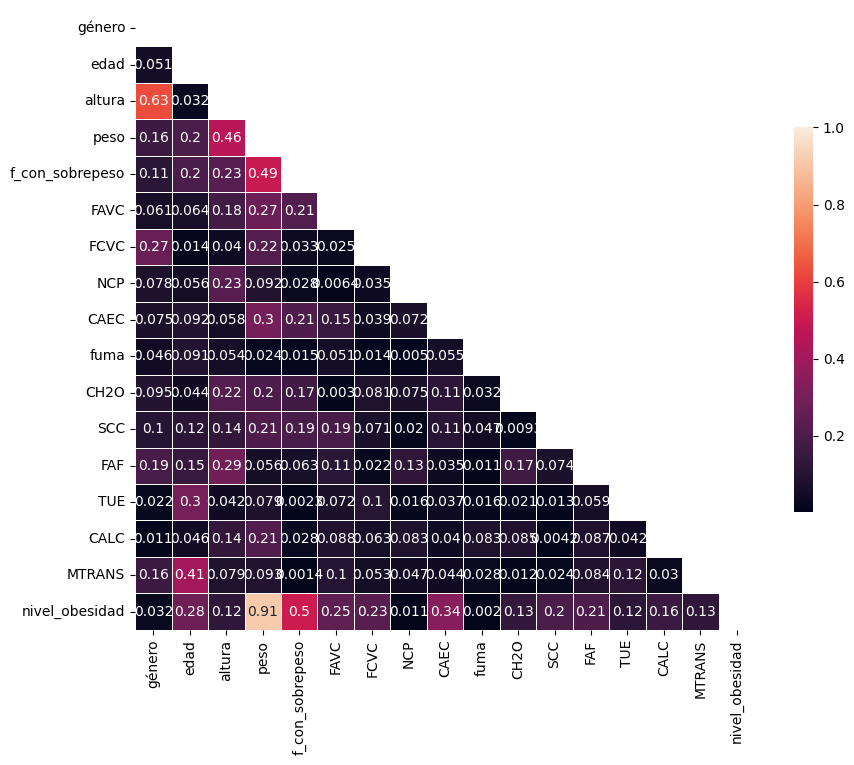

In [120]:
f.corr_heatmap(df_estudio)

Observamos que las variables que menos influyen en el nivel de obesidad son: género, NCP (Comidas principales), fuma.

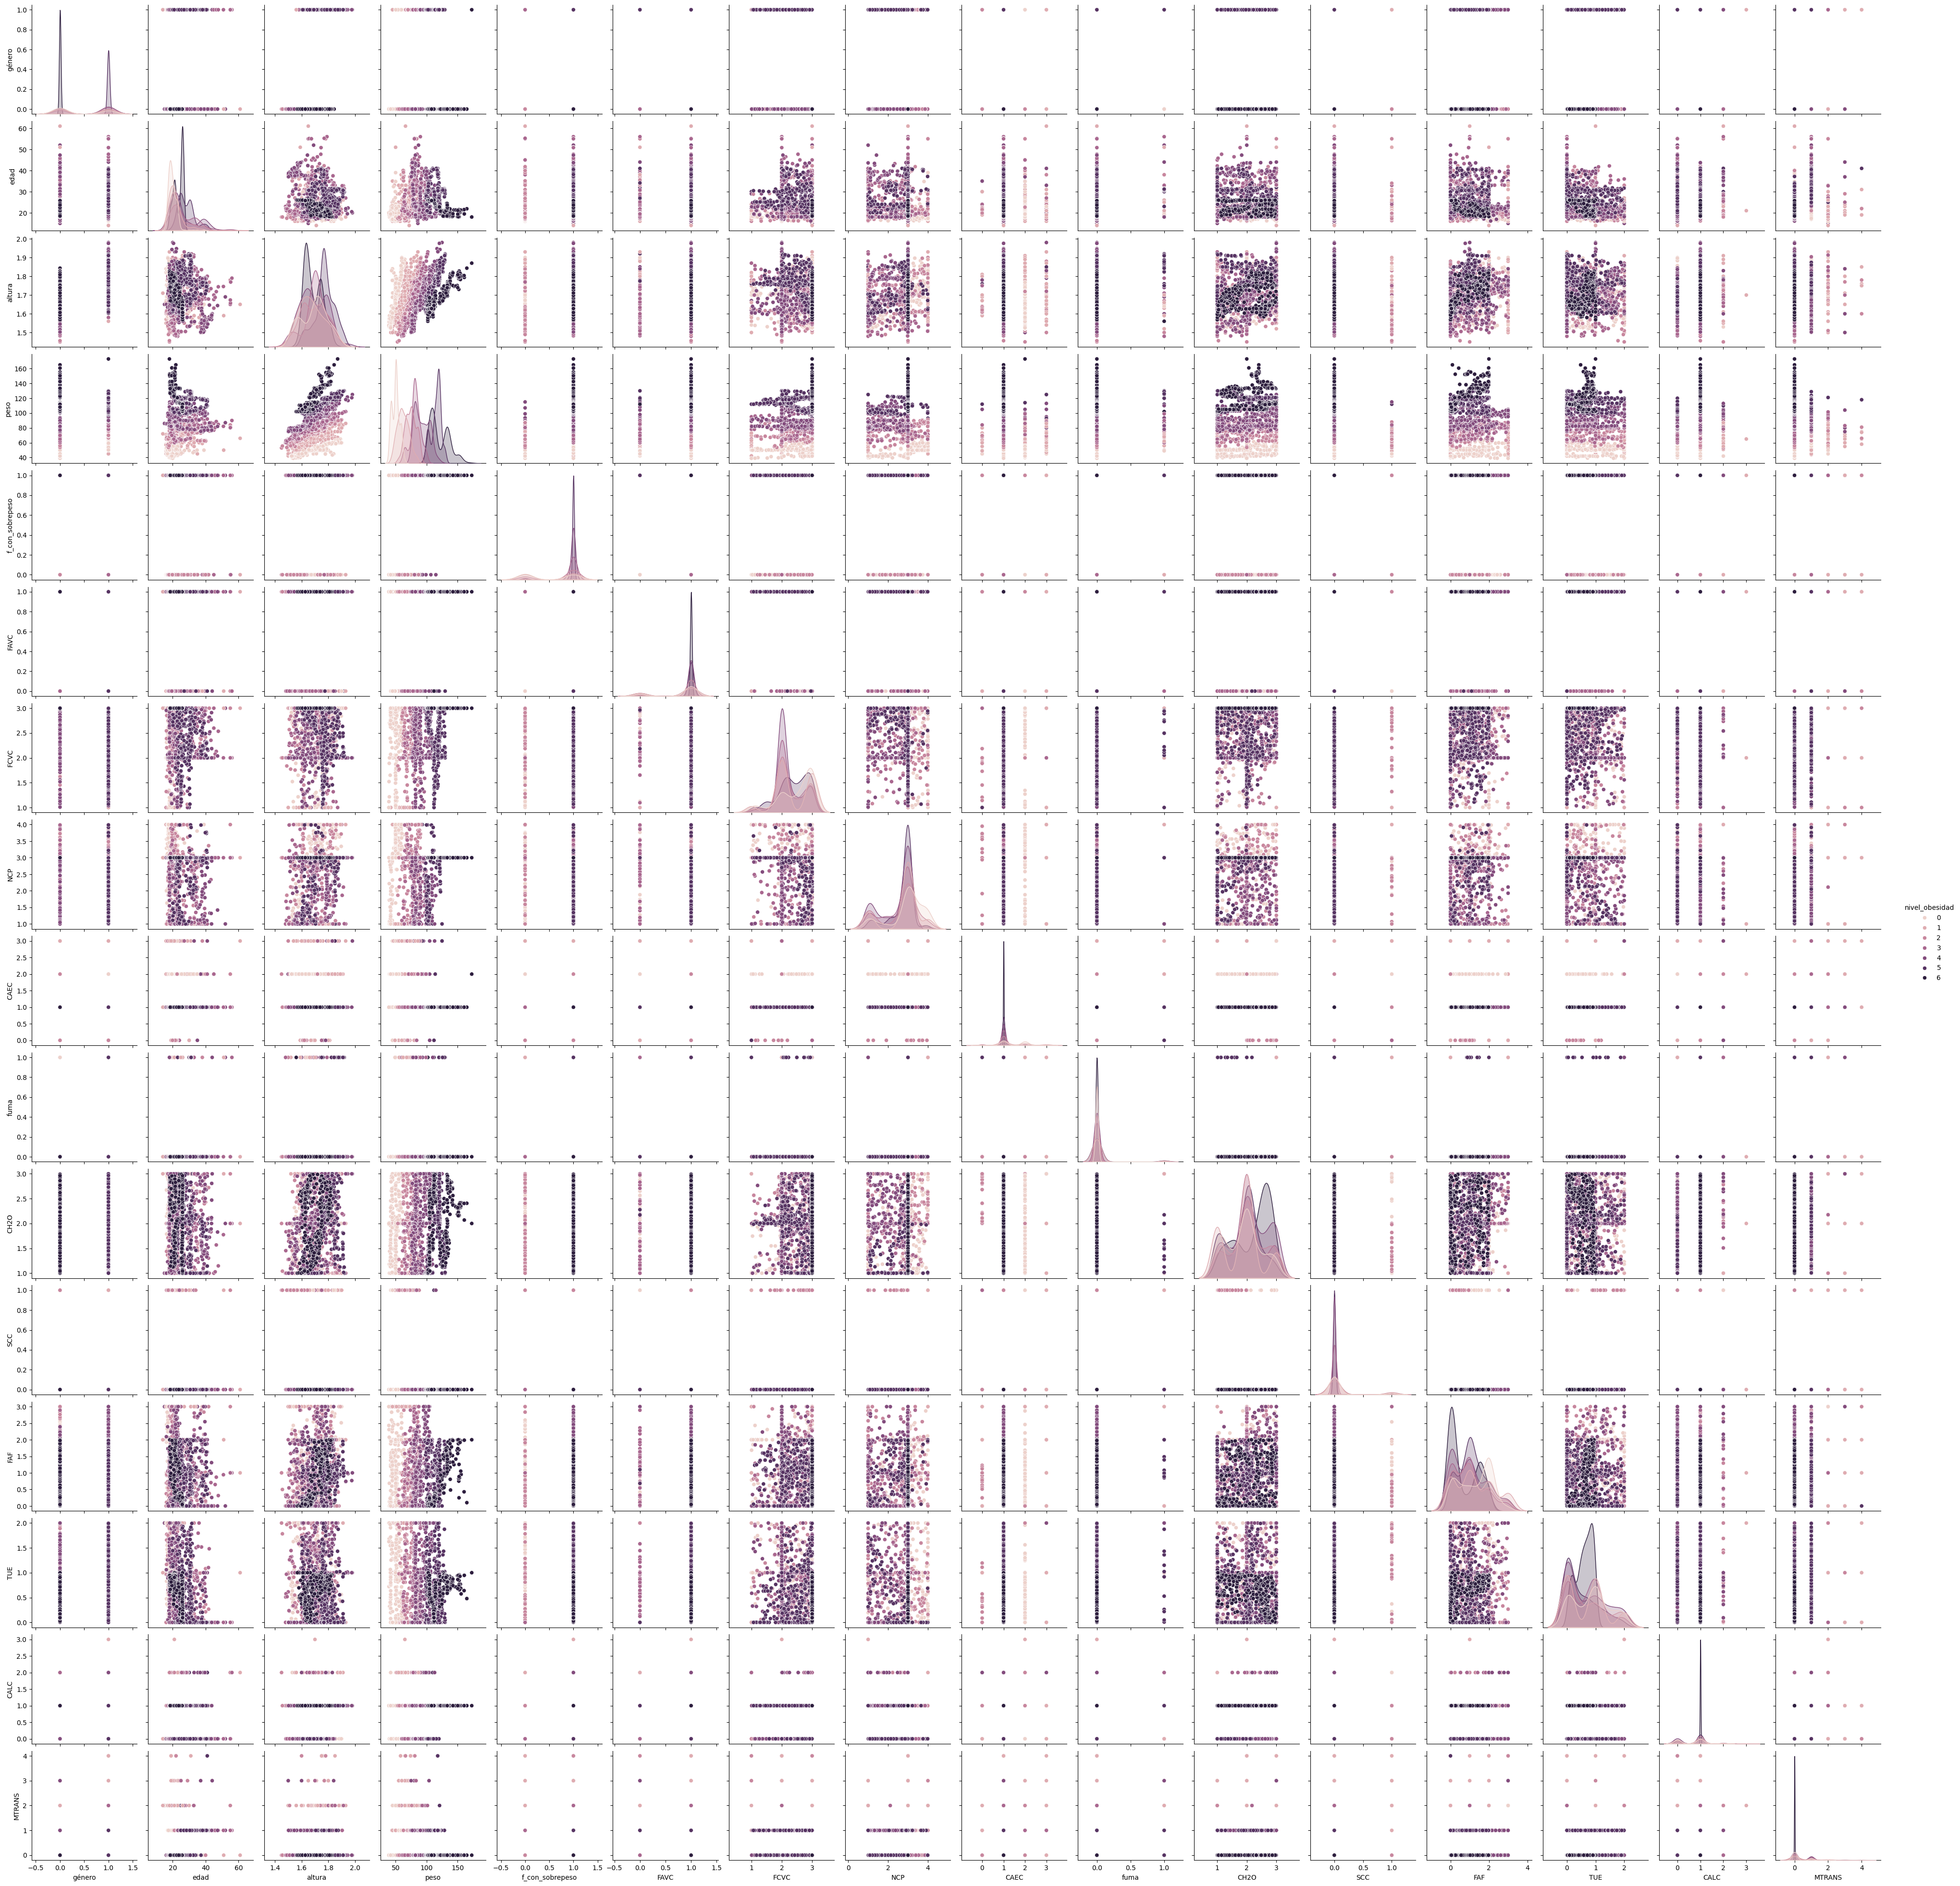

In [121]:
sns.pairplot(df_estudio, hue="nivel_obesidad")
plt.show()

Veamos el test de KNN para este estudio

In [122]:
m.knn(df_estudio,'nivel_obesidad',3)

Accuracy:
0.8827751196172249
Precision:
0.8732437845577152
Recall:
0.8732506045896619
F1-score:
0.8668122054678337
Confusion Matrix:
[[44  2  0  0  0  0  0]
 [11 26  9  3  2  0  0]
 [ 1  2 49  4  0  0  0]
 [ 0  2  2 52  2  2  0]
 [ 0  0  1  3 70  0  1]
 [ 0  0  0  0  1 68  1]
 [ 0  0  0  0  0  0 60]]


# Ahora haremos un KNN haciendo un estudio de la variable a predecir

Haremos el mapa de correlación del data analisis para determinar cuales son las variables con mayor correlación con la variable a predecir

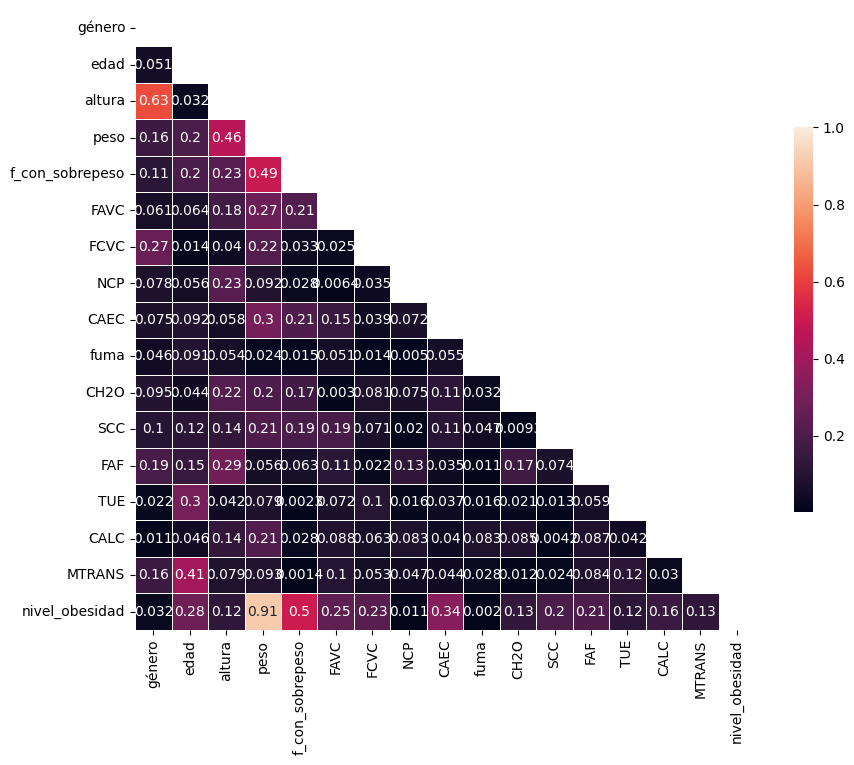

In [123]:
f.corr_heatmap(df_estudio)


Mediante la matriz de correlación, podemos ver que:
- "género", "NCP"(número de comidas principales) y "fuma" tienen una correlación bastante baja con nuestra variable objetivo que es el nivel de obesidad, por lo que las eliminaremos de nuestras características seleccionadas.

In [124]:
df_nuevo=df_estudio.drop(['género','NCP','fuma'], axis=1)

In [125]:
df_nuevo.head()

,edad,altura,peso,f_con_sobrepeso,FAVC,FCVC,CAEC,CH2O,SCC,FAF,TUE,CALC,MTRANS,nivel_obesidad
0,21.0,1.62,64.0,1,0,2.0,1,2.0,0,0.0,1.0,0,0,1
1,21.0,1.52,56.0,1,0,3.0,1,3.0,1,3.0,0.0,1,0,1
2,23.0,1.80,77.0,1,0,2.0,1,2.0,0,2.0,1.0,2,0,1
3,27.0,1.80,87.0,0,0,3.0,1,2.0,0,2.0,0.0,2,2,2
4,22.0,1.78,89.8,0,0,2.0,1,2.0,0,0.0,0.0,1,0,3


Aplicamos KNN en este nuevo dataset con los datos que tienen mayor correlación con el objetivo.

In [126]:
m.knn(df_nuevo,"nivel_obesidad",5)

Accuracy:
0.861244019138756
Precision:
0.8516450239143064
Recall:
0.8506959305461316
F1-score:
0.8420297081033665
Confusion Matrix:
[[45  1  0  0  0  0  0]
 [12 22  7  8  2  0  0]
 [ 0  2 48  6  0  0  0]
 [ 0  3  2 49  4  2  0]
 [ 0  0  1  3 70  0  1]
 [ 0  0  0  0  0 68  2]
 [ 0  0  0  0  0  2 58]]


# Haremos el estudio de los datos solo transformando las variables a numéricas

Veamos el KNN de este nuevo dataset con solo variables numéricas que nos permitan hacer predicciones

In [127]:
# Haremos la transformación de las variables categóricas en variables numéricas
df_en = pd.get_dummies(df_clean, columns=['género', 'MTRANS','f_con_sobrepeso', 'FAVC', 'fuma', 'SCC'], drop_first=True)

In [128]:
# Haremos la transformación de las variables categóricas en variables las que siguen un orden 

df_en=f.cambiar(df_en)


In [129]:
df_en.head()

,edad,altura,peso,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,nivel_obesidad,género_masculino,MTRANS_automóvil,MTRANS_bicicleta,MTRANS_motocicleta,MTRANS_transporte público,f_con_sobrepeso_Si,FAVC_Si,fuma_Si,SCC_Si
0,21.0,1.62,64.0,2.0,3.0,1,2.0,0.0,1.0,0,1,False,False,False,False,True,True,False,False,False
1,21.0,1.52,56.0,3.0,3.0,1,3.0,3.0,0.0,1,1,False,False,False,False,True,True,False,True,True
2,23.0,1.80,77.0,2.0,3.0,1,2.0,2.0,1.0,2,1,True,False,False,False,True,True,False,False,False
3,27.0,1.80,87.0,3.0,3.0,1,2.0,2.0,0.0,2,2,True,False,False,False,False,False,False,False,False
4,22.0,1.78,89.8,2.0,1.0,1,2.0,0.0,0.0,1,3,True,False,False,False,True,False,False,False,False


In [130]:
m.knn(df_en,'nivel_obesidad',3)

Accuracy:
0.8875598086124402
Precision:
0.8765090598590899
Recall:
0.8781825773787776
F1-score:
0.8715920686044295
Confusion Matrix:
[[44  2  0  0  0  0  0]
 [10 26 10  3  2  0  0]
 [ 1  2 50  3  0  0  0]
 [ 0  3  2 53  1  1  0]
 [ 0  0  1  3 70  0  1]
 [ 0  0  0  0  1 68  1]
 [ 0  0  0  0  0  0 60]]


# Haremos el estudio ahora con el dataset con mayor correlación

Mediante la matriz de correlación, podemos ver que:
- "género", "NCP"(número de comidas principales) y "fuma" tienen una correlación bastante baja con nuestra variable objetivo que es el nivel de obesidad, por lo que las eliminaremos de nuestras características seleccionadas.

In [131]:
df_2=df_clean.drop(['género','NCP','fuma'], axis=1)

In [132]:
# Haremos la transformación de las variables categóricas en variables numéricas
df_2 = pd.get_dummies(df_2, columns=['MTRANS', 'f_con_sobrepeso', 'FAVC','SCC'], drop_first=True)

In [133]:
df_2.head()

,edad,altura,peso,FCVC,CAEC,CH2O,FAF,TUE,CALC,nivel_obesidad,MTRANS_automóvil,MTRANS_bicicleta,MTRANS_motocicleta,MTRANS_transporte público,f_con_sobrepeso_Si,FAVC_Si,SCC_Si
0,21.0,1.62,64.0,2.0,A veces,2.0,0.0,1.0,no,Peso normal,False,False,False,True,True,False,False
1,21.0,1.52,56.0,3.0,A veces,3.0,3.0,0.0,A veces,Peso normal,False,False,False,True,True,False,True
2,23.0,1.80,77.0,2.0,A veces,2.0,2.0,1.0,Con frecuencia,Peso normal,False,False,False,True,True,False,False
3,27.0,1.80,87.0,3.0,A veces,2.0,2.0,0.0,Con frecuencia,Sobrepeso nivel I,False,False,False,False,False,False,False
4,22.0,1.78,89.8,2.0,A veces,2.0,0.0,0.0,A veces,Sobrepeso nivel II,False,False,False,True,False,False,False


In [134]:
#variables con un orden 
df_2=f.cambiar(df_2)


In [135]:
df_2.head()

,edad,altura,peso,FCVC,CAEC,CH2O,FAF,TUE,CALC,nivel_obesidad,MTRANS_automóvil,MTRANS_bicicleta,MTRANS_motocicleta,MTRANS_transporte público,f_con_sobrepeso_Si,FAVC_Si,SCC_Si
0,21.0,1.62,64.0,2.0,1,2.0,0.0,1.0,0,1,False,False,False,True,True,False,False
1,21.0,1.52,56.0,3.0,1,3.0,3.0,0.0,1,1,False,False,False,True,True,False,True
2,23.0,1.80,77.0,2.0,1,2.0,2.0,1.0,2,1,False,False,False,True,True,False,False
3,27.0,1.80,87.0,3.0,1,2.0,2.0,0.0,2,2,False,False,False,False,False,False,False
4,22.0,1.78,89.8,2.0,1,2.0,0.0,0.0,1,3,False,False,False,True,False,False,False


Haremos el modelo de KNN con este dataset

In [136]:
m.knn(df_2,'nivel_obesidad',3)

Accuracy:
0.8803827751196173
Precision:
0.8746459884496299
Recall:
0.8692450023487657
F1-score:
0.859209451106062
Confusion Matrix:
[[44  2  0  0  0  0  0]
 [ 9 21 11  8  2  0  0]
 [ 1  1 51  3  0  0  0]
 [ 0  1  2 55  1  1  0]
 [ 0  0  1  4 69  0  1]
 [ 0  0  0  0  0 69  1]
 [ 0  0  0  0  0  1 59]]


# Veamos el árbol de decisión

In [138]:
df_con=f.volver(df_estudio,'nivel_obesidad')

NameError: name 'columnas_obesidad' is not defined

In [139]:
m.arbol(df_estudio,"nivel_obesidad",5)

Accuracy:
0.8229665071770335
Precision:
0.8362076429191573
Recall:
0.8106372114063017
F1-score:
0.8136020283835684
Confusion Matrix:
[[43  3  0  0  0  0  0]
 [ 4 33  7  7  0  0  0]
 [ 0  1 27 27  1  0  0]
 [ 0  0  2 40 18  0  0]
 [ 0  0  0  0 74  1  0]
 [ 0  0  0  0  3 67  0]
 [ 0  0  0  0  0  0 60]]


In [ ]:
import os
# Ajusta esta ruta a donde se haya instalado Graphviz en tu PC
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'


In [ ]:
m.dibujo(df_en,'nivel_obesidad',10)

# haremos un estudio de Baggin and Panting

In [ ]:
m.baggin(df_2,'nivel_obesidad',10,10)

# Haremos un estudio de Logistic Regression

In [ ]:
m.logi_reg(df_2,'nivel_obesidad',20,20)

# Haremos un estudio de Random Forest

In [ ]:
m.random_forest(df_en,'nivel_obesidad',20,20)

# Haremos un estudio ADABoost

In [ ]:
m.adaBoost(df_en,'nivel_obesidad',20,20)

# Haremos un estudio Gradient Boosting

In [ ]:
m.gradient_boost(df_en,'nivel_obesidad',20,20)

In [140]:
df_en.head()

,edad,altura,peso,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,nivel_obesidad,género_masculino,MTRANS_automóvil,MTRANS_bicicleta,MTRANS_motocicleta,MTRANS_transporte público,f_con_sobrepeso_Si,FAVC_Si,fuma_Si,SCC_Si
0,21.0,1.62,64.0,2.0,3.0,1,2.0,0.0,1.0,0,1,False,False,False,False,True,True,False,False,False
1,21.0,1.52,56.0,3.0,3.0,1,3.0,3.0,0.0,1,1,False,False,False,False,True,True,False,True,True
2,23.0,1.80,77.0,2.0,3.0,1,2.0,2.0,1.0,2,1,True,False,False,False,True,True,False,False,False
3,27.0,1.80,87.0,3.0,3.0,1,2.0,2.0,0.0,2,2,True,False,False,False,False,False,False,False,False
4,22.0,1.78,89.8,2.0,1.0,1,2.0,0.0,0.0,1,3,True,False,False,False,True,False,False,False,False


# pruebas

In [ ]:
pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

X = df_en.drop('nivel_obesidad', axis=1)
y = df_en['nivel_obesidad']
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)
    
normalizer = MinMaxScaler()
normalizer.fit(X_train)
X_train_norm = normalizer.transform(X_train)
X_test_norm = normalizer.transform(X_test)
    
X_train_norm = pd.DataFrame(X_train_norm, columns = X_train.columns)
X_test_norm = pd.DataFrame(X_test_norm, columns = X_test.columns)
    
# 1. Instanciar el modelo XGBoost
# objective='multi:softprob' es para clasificación multiclase
# num_class=7 porque tienes 7 niveles de obesidad
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softprob',
    num_class=7,
    random_state=42
)

# 2. Entrenar el modelo
# Importante: XGBoost espera que las etiquetas (y) empiecen en 0 (0, 1, 2, 3, 4, 5, 6)
xgb_model.fit(X_train_norm, y_train)

# 3. Predicciones
y_pred_xgb = xgb_model.fit(X_train_norm, y_train).predict(X_test_norm)

# 4. Evaluación Detallada
print("--- REPORTE DE CLASIFICACIÓN XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))

# 5. Visualización de la Matriz de Confusión
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión: XGBoost')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

# 6. Comparación de Importancia de Variables (Opcional pero muy útil)
# Esto te dirá qué hábitos influyen más en la obesidad según XGBoost
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(xgb_model.feature_importances_, index=df_en.drop('nivel_obesidad', axis=1).columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Variables más influyentes (XGBoost)')
plt.show()


# Estudio sin las variables peso y altura

Eliminamos estas variables ya que existe una formula que te determina el IMC y condiciona a veces el nivel de obesidad nuestra idea es determinar el niveld de obesidad a partir de hábitos alimenticios y condicionamiento físico.

In [141]:
df_es=df_en.drop(['altura','peso'], axis=1)

Haremos lo mismo ver los modelos y compararlos como cambian los resultados

KNN primero

In [ ]:
m.knn(df_nuevo,'nivel_obesidad',5)

ahora logistica de regresión

In [ ]:
m.logi_reg(df_nuevo,'nivel_obesidad',20,20)

Ahora aplicaremos Baggin

In [ ]:
m.baggin(df_nuevo,'nivel_obesidad',20,20)

aplicaremos arboles de decision

In [ ]:
m.arbol(df_nuevo,'nivel_obesidad',20)

Usaremos Random forests

In [ ]:
m.random_forest(df_nuevo,'nivel_obesidad',20,20)

In [ ]:
m.adaBoost(df_nuevo,'nivel_obesidad',20,20)

In [ ]:
m.gradient_boost(df_nuevo,'nivel_obesidad',20,20)

El modelo AdaBoost (Adaptive Boosting) es un potente algoritmo de aprendizaje conjunto que funciona bajo la filosofía de que "muchas voces débiles juntas hacen una fuerte". 

¿Cómo funciona AdaBoost?
A diferencia de otros modelos que entrenan todo a la vez, AdaBoost es secuencial:

Aprendices débiles: Empieza creando un modelo muy simple (normalmente un "stump" o tocón, que es un árbol de decisión de un solo nivel).

Enfoque en el error: Mira qué datos clasificó mal ese primer modelo y les asigna un mayor peso.

Corrección adaptativa: El siguiente modelo se entrena dándole prioridad a esos datos "difíciles" que el anterior falló.

Votación ponderada: Al final, todos los modelos votan, pero los que fueron más precisos tienen un voto que pesa más en la decisión final. 

¿Por qué es "mejor" con estas 7 categorías de obesidad?

En problemas multiclase (7 niveles), la dificultad suele estar en que es fácil distinguir a alguien con peso normal de alguien con obesidad tipo III, pero es muy difícil distinguir entre Obesidad Tipo I y Tipo II.

Precisión: AdaBoost brilla aquí porque detecta precisamente esos casos donde los niveles de obesidad se confunden y obliga a los siguientes modelos a especializarse en diferenciarlos.

Complejidad progresiva: Al combinar muchos modelos simples, logra crear una "frontera de decisión" muy compleja que se ajusta mejor a las sutiles diferencias entre las 7 categorías, algo que un solo modelo grande a veces no logra captar con tanto detalle.

Resistencia: Aunque es sensible a datos muy atípicos, en conjuntos de datos estructurados (como los de salud) suele generalizar muy bien sin sobreajustarse tan rápido como otros modelos si los parámetros están bien ajustados. 

En resumen: AdaBoost es como un profesor que identifica qué temas (o categorías de obesidad) le cuestan más a sus alumnos y dedica las siguientes clases exclusivamente a reforzar esos puntos difíciles hasta que todos los entienden.

# Analisis con paramétros optimizados.

## Partimos con el modelo de árbol de decisión

In [144]:
best_tree=m.optimizar_arbol(df_estudio,"nivel_obesidad", 20)

Buscando los mejores parámetros... (esto puede tardar un poco)

MEJORES PARÁMETROS ENCONTRADOS:
{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'entropy', 'class_weight': None}

REPORTE DE CLASIFICACIÓN (7 Categorías):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.93      0.84      0.89        51
           2       0.87      0.93      0.90        56
           3       0.93      0.92      0.92        60
           4       0.95      0.96      0.95        75
           5       0.99      0.97      0.98        70
           6       1.00      1.00      1.00        60

    accuracy                           0.94       418
   macro avg       0.94      0.94      0.94       418
weighted avg       0.95      0.94      0.94       418

MATRIZ DE CONFUSIÓN:
[[45  1  0  0  0  0  0]
 [ 3 43  5  0  0  0  0]
 [ 0  2 52  2  0  0  0]
 [ 0  0  3 55  2  0  0]
 [ 0  0  0  2 72  1  0]
 [ 0  0  0 

In [143]:
best_tree=m.optimizar_arbol(df_en,"nivel_obesidad", 20)

Buscando los mejores parámetros... (esto puede tardar un poco)

MEJORES PARÁMETROS ENCONTRADOS:
{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'entropy', 'class_weight': 'balanced'}

REPORTE DE CLASIFICACIÓN (7 Categorías):
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.96      0.84      0.90        51
           2       0.88      0.95      0.91        56
           3       0.93      0.95      0.94        60
           4       0.95      0.96      0.95        75
           5       0.99      0.96      0.97        70
           6       1.00      1.00      1.00        60

    accuracy                           0.95       418
   macro avg       0.95      0.95      0.95       418
weighted avg       0.95      0.95      0.95       418

MATRIZ DE CONFUSIÓN:
[[45  1  0  0  0  0  0]
 [ 3 43  5  0  0  0  0]
 [ 0  1 53  2  0  0  0]
 [ 0  0  2 57  1  0  0]
 [ 0  0  0  2 72  1  0]
 [ 0  0

# Modelo KNN con optimizado

## Modelo Random Forest optimizado 

In [145]:
best_forest = m.optimizar_forest(df_estudio, 'nivel_obesidad', 20)

Entrenando Random Forest con 20 combinaciones...

MEJORES PARÁMETROS RANDOM FOREST:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        46
           1       0.81      0.94      0.87        51
           2       0.94      0.88      0.91        56
           3       0.93      0.92      0.92        60
           4       0.99      0.96      0.97        75
           5       0.99      1.00      0.99        70
           6       1.00      1.00      1.00        60

    accuracy                           0.95       418
   macro avg       0.95      0.95      0.95       418
weighted avg       0.95      0.95      0.95       418

MATRIZ DE CONFUSIÓN:
[[44  2  0  0  0  0  0]
 [ 0 48  1  2  0  0  0]
 [ 0  7 49  0  0  0  0]
 [ 0  2  1 55  1  1  0]
 [ 0  0  1  2 72  0  0]
 [ 0  0  0  0  0 70  

In [146]:
best_forest = m.optimizar_forest(df_en, 'nivel_obesidad', 20)

Entrenando Random Forest con 20 combinaciones...

MEJORES PARÁMETROS RANDOM FOREST:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'bootstrap': False}

REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        46
           1       0.82      0.96      0.88        51
           2       0.94      0.89      0.92        56
           3       0.95      0.93      0.94        60
           4       1.00      0.96      0.98        75
           5       1.00      1.00      1.00        70
           6       1.00      1.00      1.00        60

    accuracy                           0.96       418
   macro avg       0.96      0.96      0.96       418
weighted avg       0.96      0.96      0.96       418

MATRIZ DE CONFUSIÓN:
[[44  2  0  0  0  0  0]
 [ 0 49  1  1  0  0  0]
 [ 0  6 50  0  0  0  0]
 [ 0  3  1 56  0  0  0]
 [ 0  0  1  2 72  0  0]
 [ 0  0  0  0  0 70  

# Modelo 